# 💻 **Actividad 2**

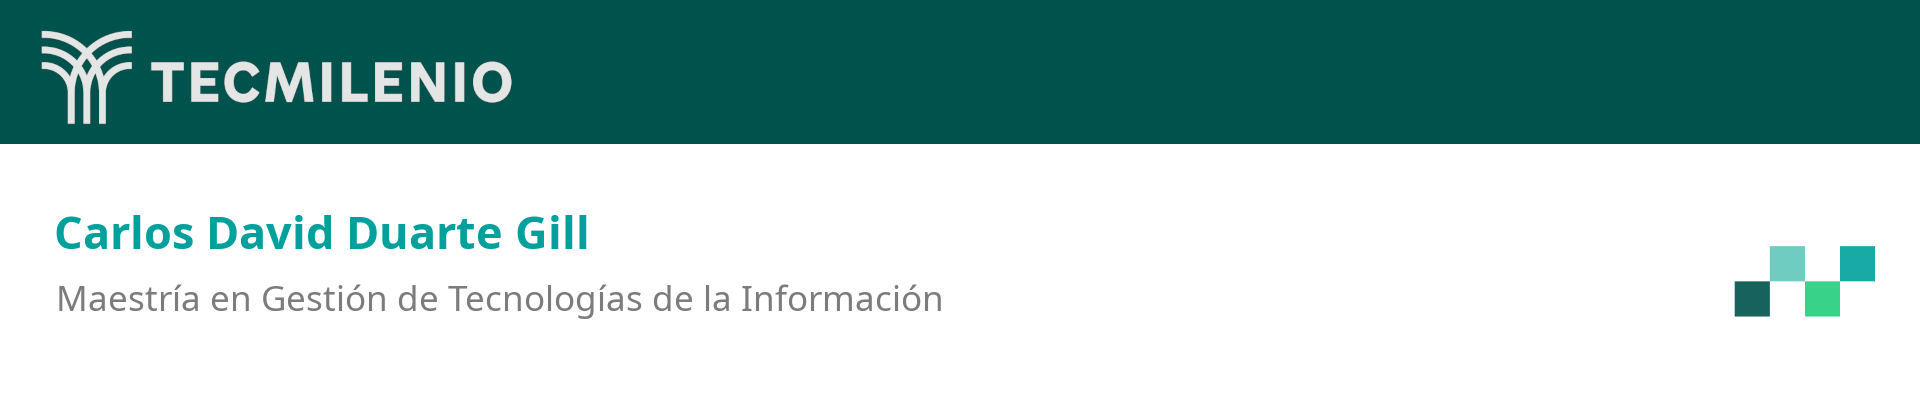

## **Aplicaciones avanzadas en ciencia de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Martín Antonio Santos Romero
- Fecha:  domingo 29 de marzo de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción – Actividad 2

En esta segunda fase del proyecto se continua revisando el escenario de NovaCredit, esta vez desde una perspectiva de predicción y descubrimiento, con la intención de entender por qué los clientes incumplen con sus pagos y si existen grupos de clientes con comportamientos similares que requieran un trato diferente. Para ello se emplearán los modelos de ensamble para aumentar la precisión de alertas de riesgo y técnicas de aprendizaje no supervisado para revelar segmentos ocultos en la cartera de clientes.

## 🗽 Alcance y alcance de la Actividad 2

El objetivo principal de esta actividad es diseñar un modelo que permita anticipar el riesgo de default y segmentar la cartera de clientes de manera estratégica en favor del negocio. Esto conlleva:

- Construir modelos predictivos utilizando algoritmos de ensamble.
- Optimizar el rendimiento de los modelos mediante la búsqueda de hiperparámetros.
- Identificar perfiles de clientes "especiales" mediante clustering para poder diseñar estrategias de cobranza y prevención personalizadas.

# 💻 Entorno Python para la Actividad 2

Se creó un nuevo entorno de trabajo optimizada para el análisis de datos masivos...

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Actividad 2 y asegurar todos los pasos requeridos durante su desarrollo, se utilizará el conjunto de datos **novacredit_clientes_limpio
.csv** preparado durante la Actividad 1.

### 📒 Acerca del conjunto de datos

El conjunto de datos preparado `novacredit_clientes_limpio.csv` cuenta con 10,000 registros y 21 variables. Este nuevo archivo representa una versión optimizada del historial de clientes, diseñada específicamente para ser interpretada por algoritmos de aprendizaje automático.

Características principales:
- El dataset original paso por un proceso de limpieza y ya no existen valores nulos ni errores de encoding detectados anteriormente.
- Todas las variables numéricas han sido escaladas previamente mediante StandardScaler.
- Las variables categóricas de texto se han transformado en representaciones numéricas mediante técnicas de One-Hot Encoding y Ordinal Encoding.
- Se aplicaron técnicas de capping para reducir el efecto de los outliers en límites de crédito y saldos.

### 🔗 Carga el conjunto de datos en url pública

Para el desarrollo de la Actividad 2 se cargo previamente el nuevo dataset en un [repositorio público en GitHub](https://raw.githubusercontent.com/RamRider89/aplicaciones-ciencia-datos/refs/heads/main/actividades/actividad-2/novacredit_clientes_limpio.csv)

# 💻 Desarrollo de la Actividad 2

**A continuación:**

🧰 Se importan las librerías necesarias para el desarrollo de los modelos necesarios.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [1]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import sys
import os
# warnings
import warnings
warnings.filterwarnings('ignore')

try:
    # liberias basicas
    import pandas as pd
    import numpy as np

    # Herramientas necesarios
    import sklearn
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
    from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, roc_auc_score

    # visualizacion
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tabulate import tabulate


    print("-" * 80)
    print("⚙️ Cargando librerías core...")
    print(f"Python: {sys.version.split()[0]}")
    print(f"Pandas version: {pd.__version__}")
    print(f"NumPy version: {np.__version__}")
    print(f"scikit-learn version: {sklearn.__version__}")


    print("-" * 80)
    print("⚙️ Cargando librerías de visualización...")
    print(f"Matplotlib - version: {plt.matplotlib.__version__}")
    print(f"Seaborn version: {sns.__version__}")
    print("-" * 80)
    print("🚀 ¡Entorno preparado!")
    print("-" * 80)

except Exception as e:
    print(f"❌ Error de entorno, favor de instalar las dependencias necesarias: {e}")

warnings.filterwarnings('ignore')

--------------------------------------------------------------------------------
⚙️ Cargando librerías core...
Python: 3.10.19
Pandas version: 2.3.3
NumPy version: 2.2.6
scikit-learn version: 1.7.2
--------------------------------------------------------------------------------
⚙️ Cargando librerías de visualización...
Matplotlib - version: 3.10.0
Seaborn version: 0.13.2
--------------------------------------------------------------------------------
🚀 ¡Entorno preparado!
--------------------------------------------------------------------------------


## 🗂 Variables de entorno

In [2]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"

# configuración de estilo visual
sns.set_theme(style="whitegrid")

### 🗂 Funciones auxiliares

In [3]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

In [4]:
# ------------------------------------------------------------------------------
# 🤖 diccionario builder
# ------------------------------------------------------------------------------

def dictionary_builder(columnas_categoricas, msj):

    _dict_unique_values_ = {}

    # recorremos las columnas categoricas para obtener sus valores
    display_mensaje(msj)
    # recorreos las columnas categoricas
    for col in columnas_categoricas.columns:
        # obtenemos los vals unicos
        unique_values = columnas_categoricas[col].unique()
        # asignamos los valores unicos al dict
        _dict_unique_values_[col] = columnas_categoricas[col].unique()


    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
    # imprimiendo
    print(tabulate(data, headers=headers, tablefmt="grid"))

    return _dict_unique_values_;

# 💾 Carga de los datos

Para iniciar el análisis se utiliza la url pública del dataset en **Canvas**.

In [5]:
# ------------------------------------------------------------------------------
# CARGA DEL DATASET
# ------------------------------------------------------------------------------
# URL pública del dataset
_URL_REPO_ = 'https://raw.githubusercontent.com/RamRider89/aplicaciones-ciencia-datos/refs/heads/main/actividades/actividad-2/novacredit_clientes_limpio.csv'
_URL_LOCAL_ = "./novacredit_clientes_limpio.csv"
_URL_ = _URL_LOCAL_
# config
pd.set_option('display.max_columns', None)

# leyendo el archivo csv mediante pandas
df_prep = pd.read_csv(_URL_)

# 🔍 Análisis exploratorio inicial

A continuación se inicia con el análisis inicial del dataset.

## 🗂 Descripción del dataframe

In [6]:
display_mensaje("Estructura inicial del DataFrame")
df_prep.head()


 --- Estructura inicial del DataFrame --- 


,edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m,region_Norte,region_Sur,canal_adquisicion_Referido,canal_adquisicion_Sucursal,canal_adquisicion_Web,tipo_producto_Préstamo,tipo_producto_Tarjeta,tipo_contrato_Mensual,metodo_pago_Efectivo,metodo_pago_Transferencia,segmento_cliente,default_12m
0,0.459957,-0.235277,-0.961132,-0.538530,-0.212932,0.463622,0.466275,1.625988,-0.488493,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1
1,-0.141845,-0.467831,3.467460,-0.314700,-0.319937,-0.169499,-0.699413,-1.098827,-0.488493,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,0
2,0.631900,-0.640340,0.661224,-0.884979,-0.847772,-0.802620,-0.466275,-0.190555,0.324172,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1
3,1.577588,-0.163460,1.099698,-0.444092,-0.938128,-1.435741,0.932550,-1.098827,0.324172,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
4,-0.227816,1.103756,0.222749,1.465018,-0.273586,-1.119180,1.165688,0.717716,0.324172,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,1


## 🗂 Información de la estructura

In [7]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   edad                        10000 non-null  float64
 1   ingreso_mensual             10000 non-null  float64
 2   antiguedad_cliente_meses    10000 non-null  float64
 3   limite_credito              10000 non-null  float64
 4   saldo_promedio              10000 non-null  float64
 5   porcentaje_utilizacion      10000 non-null  float64
 6   num_transacciones_mes       10000 non-null  float64
 7   pagos_atrasados_12m         10000 non-null  float64
 8   reclamos_12m                10000 non-null  float64
 9   region_Norte                10000 non-null  float64
 10  region_Sur                  10000 non-null  float64
 11  canal_adquisicion_Referido  10000 non-null  float64
 12  canal_adquisicion_Sucursal  10000 non-null  float64
 13  canal_adquisicion_Web       1000

In [8]:
display_mensaje("Estructura del Dataset")
print(f"Dataset shape: {df_prep.shape}")
print(f"Número de filas: {df_prep.shape[0]}")
print(f"Número de columnas: {df_prep.shape[1]}")


 --- Estructura del Dataset --- 
Dataset shape: (10000, 21)
Número de filas: 10000
Número de columnas: 21


### 🕵️‍♂️ Tipos de datos

A continuación, se detalla la estructura del nuevo dataset resultante tras el preprocesamiento de limpieza:

| Categoría             | Variable(s)                                                                                                                                                       | Tipo de Dato | Transformación Aplicada | Propósito en el Modelo                                                                                        |
| --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------ | ----------------------- | ------------------------------------------------------------------------------------------------------------- |
| Numéricas Escaladas   | edad, ingreso_mensual, antiguedad_cliente_meses, limite_credito, saldo_promedio, porcentaje_utilizacion, num_transacciones_mes, pagos_atrasados_12m, reclamos_12m | float64      | StandardScaler          | Capturar la magnitud y varianza de los indicadores financieros y de comportamiento sin sesgos por escala.     |
| Geográficas (Nominal) | region_Norte, region_Sur                                                                                                                                          | float64      | One-Hot Encoding        | Identificar patrones de riesgo específicos por ubicación geográfica.                                          |
| Origen (Nominal)      | canal_adquisicion_Referido, canal_adquisicion_Sucursal, canal_adquisicion_Web                                                                                     | float64      | One-Hot Encoding        | Evaluar si el canal de entrada del cliente influye en la probabilidad de default.                             |
| Producto (Nominal)    | tipo_producto_Préstamo, tipo_producto_Tarjeta                                                                                                                     | float64      | One-Hot Encoding        | Diferenciar el comportamiento de riesgo según el instrumento financiero contratado.                           |
| Contrato (Nominal)    | tipo_contrato_Mensual                                                                                                                                             | float64      | One-Hot Encoding        | Analizar la estabilidad del cliente según la duración de su compromiso contractual.                           |
| Pago (Nominal)        | metodo_pago_Efectivo, metodo_pago_Transferencia                                                                                                                   | float64      | One-Hot Encoding        | Detectar si ciertos métodos de pago están correlacionados con el incumplimiento.                              |
| Perfil (Ordinal)      | segmento_cliente                                                                                                                                                  | float64      | Ordinal Encoding        | Representar la jerarquía de valor del cliente (Básico < Plus < Premium) mediante valores numéricos (0, 1, 2). |
| Objetivo (Target)     | default_12m                                                                                                                                                       | int64        | Ninguna                 | Variable a predecir: indica si el cliente incumplió sus pagos (1) o no (0).                                   |

# 🕵️‍♂️ Verificación técnica del dataset

Para garantizar que el Actividad 2 se desarrolle sobre un dataset confiable, se realiza a continuación una verificación técnica del dataset preparado.

## 🔍 Verificación de integridad y consistencia

En este bloque se confirma que el escalamiento sea correcto revisando que la media sea cercana a 0 y la desviación estándar cercana a 1, y que no hayan quedado valores de nulos o valores infinitos.

In [9]:
# ------------------------------------------------------------------------------
# Verificación de integridad y consistencia
# ------------------------------------------------------------------------------
def verificar_consistencia(df):
    display_mensaje("Verificación de integridad y consistencia")
    
    # comprobar nulos
    nulos = df.isnull().sum().sum()
    
    # comprobar valores infinitos
    infinitos = np.isinf(df.select_dtypes(include=np.number)).values.sum()
    
    # validar escalamiento solo en variables float64 que fueron estandarizadas
    cols_escaladas = ['edad', 'ingreso_mensual', 'antiguedad_cliente_meses', 'limite_credito', 
                      'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes', 
                      'pagos_atrasados_12m', 'reclamos_12m']
    
    mean_check = df[cols_escaladas].mean().abs().mean()
    std_check = df[cols_escaladas].std().mean()

    print(f"Total de nulos: {nulos}")
    print(f"Total de infinitos: {infinitos}")
    print(f"Media promedio: {mean_check:.6f}")
    print(f"Desviación estándar promedio: {std_check:.6f}")
    
    if nulos == 0 and infinitos == 0 and abs(mean_check) < 0.1:
        print("\n✅ RESULTADO: Dataset consistente para modelación.")
    else:
        print("\n⚠️ ADVERTENCIA: Se detectaron inconsistencias en el dataset.")

verificar_consistencia(df_prep)


 --- Verificación de integridad y consistencia --- 
Total de nulos: 0
Total de infinitos: 0
Media promedio: 0.000000
Desviación estándar promedio: 1.000050

✅ RESULTADO: Dataset consistente para modelación.


## 🔍 Análisis de capacidad predictiva

En este bloque se visualiza rápidamente cuáles son las variables de mayor influencia en el negocio de NovaCredit. Esto nos ayudará a entender mejor el dataset para el diseño del modelo.


 --- Análisis de capacidad predictiva - Objetivo: default_12m --- 


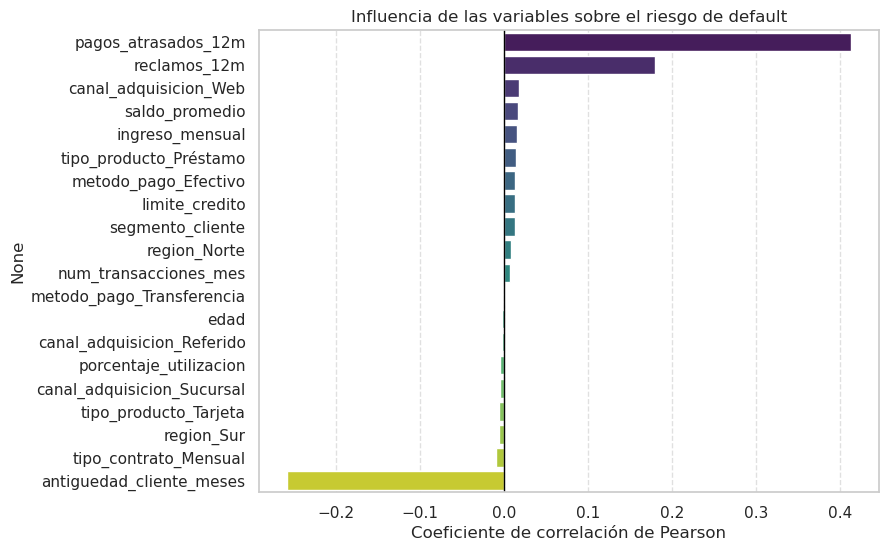


 --- Top 3 variables que aumentan el riesgo --- 
pagos_atrasados_12m      0.412465
reclamos_12m             0.179838
canal_adquisicion_Web    0.017374
Name: default_12m, dtype: float64

 --- Top 3 variables que disminuyen riesgo --- 
region_Sur                 -0.005927
tipo_contrato_Mensual      -0.009092
antiguedad_cliente_meses   -0.258161
Name: default_12m, dtype: float64


In [10]:
# ------------------------------------------------------------------------------
# 🔍 Análisis de capacidad predictiva
# ------------------------------------------------------------------------------
def analizar_predictoras(df):
    # objetivo
    target='default_12m'
    
    display_mensaje("Análisis de capacidad predictiva - Objetivo: default_12m")
    
    # calcular correlación de Pearson
    correlaciones = df.corr()[target].sort_values(ascending=False)
    
    # visualización
    plt.figure(figsize=(8, 6))
    # datos graficos sin el objetivo
    correlaciones_plot = correlaciones.drop(target)
    
    sns.barplot(
                x=correlaciones_plot.values, 
                y=correlaciones_plot.index, 
                palette='viridis')
    
    plt.title('Influencia de las variables sobre el riesgo de default')
    plt.xlabel('Coeficiente de correlación de Pearson')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()
    
    # resultados del top 3 mas influyentes
    display_mensaje("Top 3 variables que aumentan el riesgo")
    print(correlaciones_plot.head(3))
    display_mensaje("Top 3 variables que disminuyen riesgo")
    print(correlaciones_plot.tail(3))

analizar_predictoras(df_prep)

## 🔍 Verificación de desbalance en variable objetivo

Como ya se reviso en la Actividad 1, la variable objetivo esta mayormente cargada hacia la derecha. En este bloque verificaremos dicho balance de información para poder decidir que técnicas son más factibles para el nuevo dataset.

In [11]:
# ------------------------------------------------------------------------------
# 🔍 Verificación de desbalance de clases
# ------------------------------------------------------------------------------
def verificar_desbalance(df):
    # objetivo
    target='default_12m'

    display_mensaje("Verificación de desbalance en default_12m")
    counts = df[target].value_counts()
    percentage = df[target].value_counts(normalize=True) * 100
    
    resumen = pd.DataFrame({'Cantidad': counts, 'Porcentaje': percentage})
    print(resumen)
    
    if percentage.min() < 30:
        print(f"\n⚠️ AVISO: Existe un desbalance significativo ({percentage.min():.2f}%).")

verificar_desbalance(df_prep)


 --- Verificación de desbalance en default_12m --- 
             Cantidad  Porcentaje
default_12m                      
1                7584       75.84
0                2416       24.16

⚠️ AVISO: Existe un desbalance significativo (24.16%).


Dado el desbalance significativo, se recomienda usar métricas como F1-Score y AUC-PR en lugar de Accuracy.

# 🤖 Modelado supervisado con algoritmos de ensamble

A continuación se inicia con el proceso para diseñar el modelo que sea capaz de capturar las características más complejos de los clientes de NovaCredit.

## 🪶 Justificación del algoritmo

Después de una par de pruebas se ha seleccionado el algoritmo Random Forest como base para el modelo principal de ensamble, el algoritmo estará configurado específicamente para manejar el desbalance de la cartera de clientes frente al riesgo.

### 📄 Justificación técnica y de negocio:

La ventaja del Random Forest es que permite incorporar el **hiperparámetro** *class_weight='balanced'* con lo que se puede penalizar al modelo si se equivoca al clasificar a la clase minoritaria, que son los clientes con buen historial crediticio y los cuales representan aprox el 25% del total. De esta manera se obliga al modelo a prestarle una atención adecuada a cada clase de clientes para su optimo modelado. Adicional a esto, la estrategia es entrenar múltiples árboles sobre submuestras aleatorias, con la intención de que el modelo aprenda de las reglas generales del incumplimiento por parte de los clientes.

Para finalizar, el Random Forest permitirá obtener la importancia de las variables claves, con lo cual será posible explicar de mejor manera a la alta dirección por qué el modelo toma ciertas decisiones.

## 🤺  Estrategia de validación y optimización

La estrategia de validación para el Random Forest será mediante una **validación cruzada estratificada** con *StratifiedKFold*, para ello se dividirán los datos en 5 "pliegues". Con el uso de la estratificación se garantiza que cada pliegue mantenga exactamente la proporción 75% default / 25% no-default que caracteriza a nuestro dataset.

Adicional se aplicará una búsqueda aleatoria con RandomizedSearchCV impulsada por los hiperparámetros encontrados

## ⚙️ Algoritmo de ensamble

In [12]:
# ------------------------------------------------------------------------------
# Algoritmo de ensamble
# ------------------------------------------------------------------------------
# definicion de x, y
_TARGET_ = 'default_12m'
X = df_prep.drop(_TARGET_, axis=1)
y = df_prep[_TARGET_]

# división de datos para validación
# se resguarda un 20% de los datos que el modelo no verá durante la optimización
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ------------------------------------------------------------------------------
# dfinición del modelo base
# class_weight='balanced' es crítico para el 75/25 de NovaCredit
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# ------------------------------------------------------------------------------
# busqueda de hiperparametros
param_dist = {
    'n_estimators': [100, 200, 300, 500],          # cantidad de arboles
    'max_depth': [5, 10, 15, None],                # profundidad maxima
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']               # variables a considerar en cada división
}

# ------------------------------------------------------------------------------
# configuración de validación cruzada
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------------------------
# ejecución de RandomizedSearchCV
# mediante n_iter=20 se indica que probará 20 combinaciones aleatorias del diccionario param_dist
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',  # ROC-AUC
    cv=cv_estratificada,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

display_mensaje("Iniciando optimización de hiperparámetros. Esto puede tomar un momento...")
random_search.fit(X_train, y_train)


 --- Iniciando optimización de hiperparámetros. Esto puede tomar un momento... --- 
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.5s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.5s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.5s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.5s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.6s
[CV] END 

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### En cuanto a los hiperparámetros evaluados

En el bloque de búsqueda de hiperparámetros se definió el numero de arboles así como la profundidad de la evaluación, en este contexto, el número de árboles representa el tamaño de un grupo de evaluación, es importante considerar que entre más árboles tengamos en el modelo, mejor será la estabilidad de la predicción y reducción de la varianza. En este caso se el modelo evalua entre 100 y 500 arboles para encontrar el punto optimo.

Otro hiperparámetro importante es la profundidad máxima, la cual controla directamente la complejidad del modelo en sí. Cabe recalcar que en las diferentes pruebas realizadas se ha podido percibir que si se aumenta el limite de profundidad se podría estar creando un sobreajuste en los cliente. Es por ello que al limitarlo a 5, 10 o 15 se obliga al modelo a generalizar reglas aplicables a toda la cartera de clientes.

### 📄 Resultados de la optimización

In [13]:
# ------------------------------------------------------------------------------
# 📄 Resultados de la optimización
# ------------------------------------------------------------------------------
display_mensaje("Resultados de la optimización")
print(f"Mejor ROC-AUC en validación cruzada: {random_search.best_score_:.4f}")
display_mensaje("Mejores Hiperparámetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

# el mejor modelo
mejor_rf = random_search.best_estimator_


 --- Resultados de la optimización --- 
Mejor ROC-AUC en validación cruzada: 0.8795

 --- Mejores Hiperparámetros encontrados: --- 
 - n_estimators: 100
 - min_samples_split: 10
 - min_samples_leaf: 1
 - max_features: log2
 - max_depth: 10
